# ClassicModels Sales Analysis

This project analyzes sales data from the ClassicModels database using SQL and Python.

The goal is to extract data from a relational database, transform it with pandas, calculate business metrics, analyze revenue performance, and identify product portfolio risks based on revenue concentration.

## Business Questions

This project focuses on the following questions:

1. What are the main revenue trends over time?
2. Which product lines generate the highest revenue?
3. Which products are the main revenue drivers?
4. How concentrated is revenue among top products?
5. Are some product lines overly dependent on a small number of products?
6. What insights can support product and sales decisions?

## Tools Used

- Python
- pandas
- SQL
- MySQL
- SQLAlchemy
- Matplotlib
- Seaborn
- Excel



## 1. Setup and Database Connection

This section imports the required Python libraries and creates a secure connection to the MySQL database using environment variables from a `.env` file.

Required libraries are listed in `requirements.txt`.

In [1]:
import datetime
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

C:\Users\viver\AppData\Local\Temp\ipykernel_6476\73443048.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def create_connection():
    """ Create a SQLAlchemy engine  """
    # Завантажуємо змінні середовища
    load_dotenv(dotenv_path=Path("../.env"), override=True)

    # Отримуємо параметри з environment variables
    host = os.getenv('DB_HOST', 'localhost')
    port = os.getenv('DB_PORT', '3306')
    user = os.getenv('DB_USER')
    password = os.getenv('DB_PASSWORD')
    database = os.getenv('DB_NAME')

    # Перевіряємо, чи всі обов'язкові параметри задані
    if not all([user, password, database]):
        raise ValueError("Database credentials are missing. Check the .env file!")

    # Створюємо connection string
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо SQLAlchemy engine з connection pooling
    engine = create_engine(
        connection_string,
        pool_size=2,            # Розмір пулу підключень
        max_overflow=20,        # Максимальна кількість додаткових підключень
        pool_pre_ping=True,     # Перевірка підключення перед використанням
        echo=False              # Логування SQL запитів (True для debug)
    )

    # Тестуємо підключення
    try:
        with engine.connect() as conn:
            result = conn.execute(text("SELECT 1"))
            result.fetchone()

        print("✅ Database connection successful!")

        return engine

    except Exception as error:
        print(f"❌ Database connection failed: {error}")
        return None

# Створюємо підключення
engine = create_connection()

✅ Database connection successful!


## 2. Data Extraction from SQL

The analysis starts with extracting data from the ClassicModels database using SQL queries and `pd.read_sql()`.

As an initial check, the query below returns the top 10 products with the highest quantity in stock.

In [3]:
# SQLAlchemy text()

top_stock_query = text("""
    SELECT productName, productLine, quantityInStock, buyPrice
    FROM products
    ORDER BY quantityInStock DESC
    LIMIT 10
""")

df_top_stock_products = pd.read_sql(
    top_stock_query,
    engine
)

display(df_top_stock_products)

,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96


## 3. Order Analysis for 2004

This section extracts detailed order-level data for 2004 from the ClassicModels database.

The query joins orders, customers, and order details tables to calculate the total amount of each order. The resulting dataset is used to analyze revenue by country and identify key customers in the strongest markets.

In [4]:
orders_2004_query = text("""
    SELECT o.orderNumber, o.orderDate, o.status,
        c.customerName, c.country,
        SUM(d.quantityOrdered * d.priceEach) AS total_order_amount
    FROM orders AS o
    JOIN customers AS c
    ON o.customerNumber = c.customerNumber
    JOIN orderdetails AS d
    ON o.orderNumber = d.orderNumber
    WHERE o.orderDate BETWEEN :start_date AND :end_date
    GROUP BY o.orderNumber, o.orderDate, o.status, c.customerName, c.country
    ORDER BY o.orderDate
""")

start_date = datetime.date(2004, 1, 1)
end_date = datetime.date(2004, 12, 31)

df_orders_2004 = pd.read_sql(
    orders_2004_query,
    engine,
    params={"start_date": start_date,"end_date": end_date}
)

print("Orders 2004 info:")
display(df_orders_2004.head())

Orders 2004 info:


,orderNumber,orderDate,status,customerName,country,total_order_amount
0,10208,2004-01-02,Shipped,"Saveley & Henriot, Co.",France,49614.72
1,10209,2004-01-09,Shipped,"Men 'R' US Retailers, Ltd.",USA,21053.69
2,10210,2004-01-12,Shipped,Osaka Souveniers Co.,Japan,47177.59
3,10211,2004-01-15,Shipped,Auto Canal+ Petit,France,49165.16
4,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55


The resulting dataset contains one row per order and includes customer, country, order status, order date, and calculated order amount. This table will be used as the base dataset for the following revenue analysis.

### 3.1 Revenue by Country

This section summarizes total order revenue by country to identify the strongest markets in 2004.

In [5]:
# стовпчаста діаграма суми замовлень по країнам (найбільший revenue)

country_sales = (df_orders_2004
    .groupby("country")["total_order_amount"]
    .sum()
    .sort_values(ascending=False))
country_sales

display(country_sales)

country
USA            1526499.65
France          506660.01
Spain           439881.84
UK              238193.93
New Zealand     233362.27
Australia       204213.18
Italy           179108.40
Germany         133831.70
Japan           133326.77
Canada          123404.03
Switzerland     108777.92
Singapore       108032.41
Sweden          107829.78
Denmark         107232.63
Finland          78948.21
Belgium          74335.37
Norway           52514.46
Ireland          49898.27
Austria          49233.67
Norway           44798.17
Philippines      15822.84
Name: total_order_amount, dtype: float64

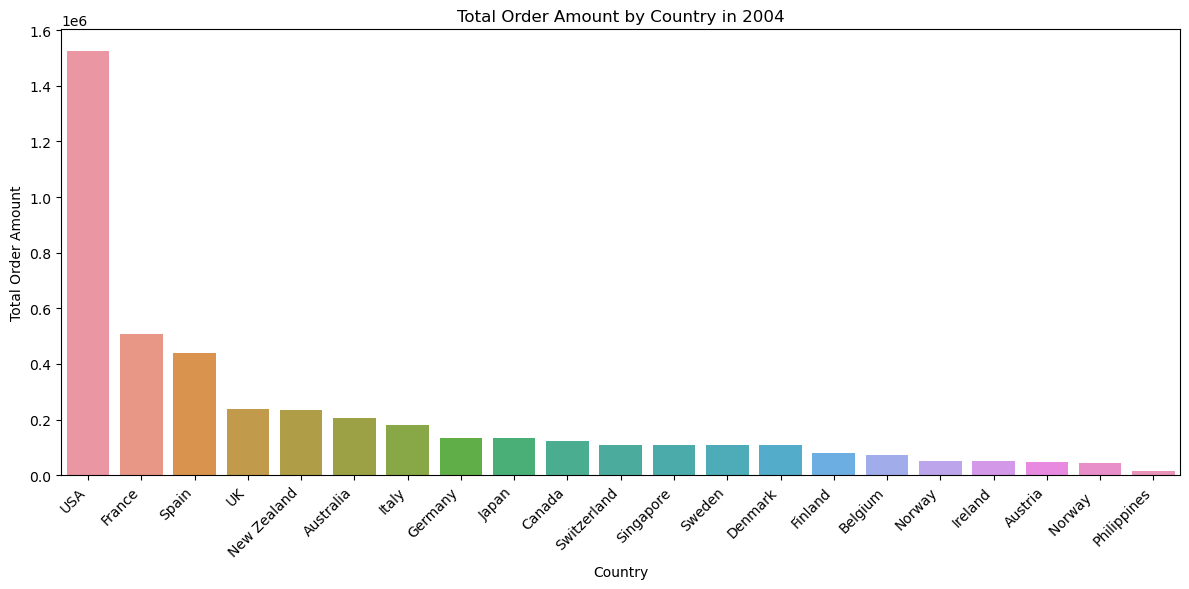

In [6]:
# стовпчаста діаграма суми замовлень по країнам - seaborn

plt.figure(figsize=(12,6))
sns.barplot(
    x=country_sales.index,
    y=country_sales.values
)

plt.title("Total Order Amount by Country in 2004")
plt.xlabel("Country")
plt.ylabel("Total Order Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/Total_Order_Amount_by_Country_in2004.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
top_sales_country = country_sales.idxmax()
top_sales_amount = country_sales.max()

# країна з найбільшою сумою замовлень (найбільший revenue)
print(f"Country with the highest total order amount in 2004: {top_sales_country}")
print(f"Total order amount: {top_sales_amount:,.2f}")

Country with the highest total order amount in 2004: USA
Total order amount: 1,526,499.65


### 3.2 Country with the Highest Number of Orders
This section identifies the country with the highest number of unique orders in 2004.

In [8]:
# країна з найбільшою кількістю замовлень 

country_orders_count = df_orders_2004.groupby("country")["orderNumber"].nunique().sort_values(ascending=False)

display(country_orders_count)

country
USA            53
France         19
Spain          14
UK              7
New Zealand     6
Australia       6
Italy           5
Germany         4
Denmark         4
Singapore       4
Canada          4
Sweden          4
Japan           4
Finland         3
Belgium         3
Ireland         2
Austria         2
Norway          2
Norway          2
Switzerland     2
Philippines     1
Name: orderNumber, dtype: int64

In [9]:
# країна з найбільшою кількістю замовлень 

top_orders_country = country_orders_count.idxmax()
top_orders_count = country_orders_count.max()

# Країна з найбільшою кількістю замовлень
print(f"Country with the highest number of orders: {top_orders_country}")
print(f"Number of orders: {top_orders_count}")

Country with the highest number of orders: USA
Number of orders: 53


In [10]:
# країна з найбільшою кількістю замовлень 

df_top_orders_country = df_orders_2004[
    df_orders_2004["country"] == top_orders_country
]

display(df_top_orders_country.head())

,orderNumber,orderDate,status,customerName,country,total_order_amount
1,10209,2004-01-09,Shipped,"Men 'R' US Retailers, Ltd.",USA,21053.69
7,10215,2004-01-29,Shipped,West Coast Collectables Co.,USA,36070.47
11,10219,2004-02-10,Shipped,Signal Collectibles Ltd.,USA,12573.28
14,10222,2004-02-19,Shipped,Collectable Mini Designs Co.,USA,56822.65
18,10226,2004-02-26,Shipped,Collectable Mini Designs Co.,USA,23552.59


### 3.3 Top Customer in the Leading Country

This section identifies the customer with the highest order value in the country with the largest number of orders.

In [11]:
# в ній -хто замовив на найбільшу суму

customer_order_amount = (
    df_top_orders_country
    .groupby("customerName")["total_order_amount"]
    .sum()
    .sort_values(ascending=False)
)

display(customer_order_amount.head())

customerName
Mini Gifts Distributors Ltd.    231562.53
Land of Toys Inc.               126792.53
Diecast Classics Inc.            98509.25
Marta's Replicas Co.             90545.37
Collectable Mini Designs Co.     80375.24
Name: total_order_amount, dtype: float64

In [12]:
# топ клієнт

top_customer = customer_order_amount.idxmax()
top_customer_amount = customer_order_amount.max()

# клієнт, який зробив замовлень на найбільшу суму
print(f"Top customer in {top_orders_country}: {top_customer}")
print(f"Total order amount: {top_customer_amount:,.2f}")


Top customer in USA: Mini Gifts Distributors Ltd.
Total order amount: 231,562.53


In [13]:
# який % від всіх замовлень в цій країні становить його сума замовлень за рік

total_top_country_sales = df_top_orders_country["total_order_amount"].sum()
top_customer_share = (top_customer_amount / total_top_country_sales * 100)

# % замовлень топ-клієнта за 2004рік, від усіх замовлень в країні:
print(
    f"Top customer share in {top_orders_country}: "
    f"{top_customer_share:.2f}%"
)

Top customer share in USA: 15.17%


### Insight

The bar chart shows that the United States significantly outperforms other countries by total order amount in 2004. This makes the USA the company’s key revenue market for the analyzed period.

Within the USA, Mini Gifts Distributors Ltd. was identified as the top customer by total order amount, accounting for approximately 15% of the country’s annual order amount.

This is an important business insight: losing such a large customer could have a noticeable impact on revenue. If several customers represent a large share of sales, the company may become highly dependent on a small number of key accounts. Therefore, customer concentration should be monitored, and revenue diversification should be considered.

## 4. Product Performance and Revenue Concentration

This section analyzes product-level revenue performance and revenue concentration across product lines.

The goal is to identify the top revenue-generating products, understand how much each product contributes to total revenue, and detect product lines that depend heavily on a small number of products.

In [14]:
product_revenue_query = text("""
    WITH product_revenue_cte AS (
        SELECT
            p.productName, p.productLine,
            SUM(od.quantityOrdered * od.priceEach) AS revenue
        FROM products AS p
        JOIN orderdetails AS od
        ON p.productCode = od.productCode
        GROUP BY
            p.productName, p.productLine
    )
    SELECT
        productName, productLine, revenue,
        DENSE_RANK() OVER (ORDER BY revenue DESC) AS revenue_rank,
        (revenue / SUM(revenue) OVER ()) * 100 AS pct_of_total,
        ((revenue - AVG(revenue) OVER (PARTITION BY productLine)) / AVG(revenue) OVER (PARTITION BY productLine)) * 100 AS pct_diff_from_line_avg
    FROM product_revenue_cte
    ORDER BY pct_of_total DESC;
""")

df_product_revenue = pd.read_sql(
    product_revenue_query,
    con=engine
)

# Аналіз доходності продуктів
print("product-level revenue:")
display(df_product_revenue.head())

product-level revenue:


,productName,productLine,revenue,revenue_rank,pct_of_total,pct_diff_from_line_avg
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.882403,165.776421
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.986112,83.132544
2,1952 Alpine Renault 1300,Classic Cars,190116.54,3,1.979456,82.518773
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.777149,97.831290
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.681834,55.076079


The resulting table contains product-level revenue, product revenue rank, percentage contribution to total company revenue, and the percentage difference from the average revenue within the same product line.

In [15]:
# % від загального доходу складає ТОП1 продукт

top_product = df_product_revenue.iloc[0]

# ТОП1 продукт та його відсоток від загального доходу
print(f"Top product: {top_product['productName']}")
print(f"Share of total revenue: {top_product['pct_of_total']:.2f}%")

Top product: 1992 Ferrari 360 Spider red
Share of total revenue: 2.88%


### Insight

The top revenue-generating product is 1992 Ferrari 360 Spider red. It accounts for about 2.88% of total company revenue. This relatively small share indicates that total revenue is not overly dependent on a single product.

### 4.1 Top 10 Products by Revenue

In [16]:
# стовпчиковa діаграмa топ-10 продуктів по доходу

top_10_products = df_product_revenue.head(10)

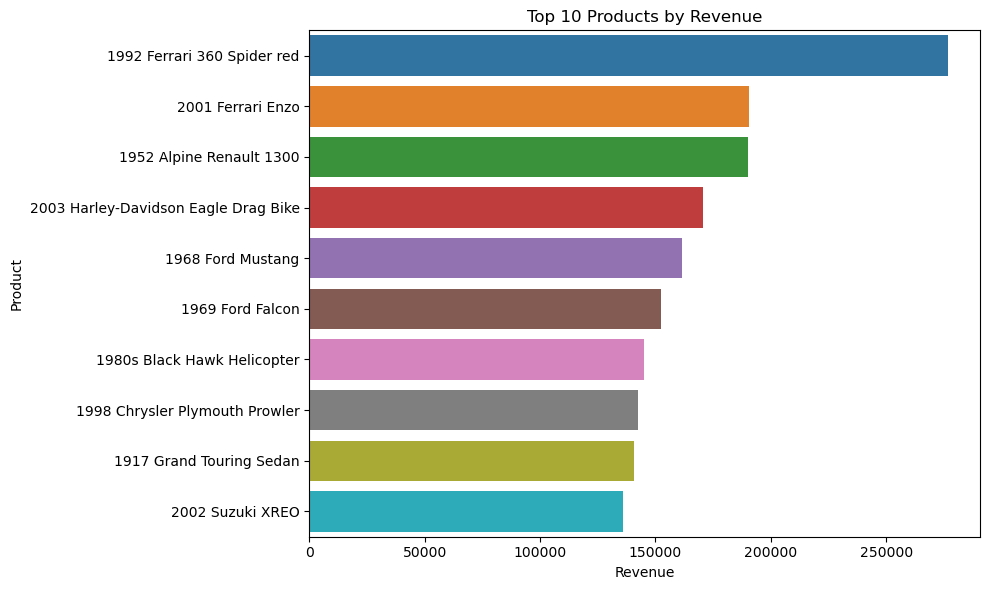

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_products,
    y="productName",
    x="revenue"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("../images/Top10_Products_by_Revenue.png", dpi=300, bbox_inches="tight")
plt.show()

###  4.2 Ratio top-1 to 10th product

In [18]:
# В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
# ratio
revenue_top_1 = top_10_products.iloc[0]["revenue"]
revenue_top_10 = top_10_products.iloc[9]["revenue"]
top_1_to_top_10_ratio = revenue_top_1 / revenue_top_10

# сумарний дохід за ТОП1 продуктом відрізняється від 10го продукту в X разів:
print(
    f"The revenue of the top product is "
    f"{top_1_to_top_10_ratio:.2f} times higher than the 10th product."
)

The revenue of the top product is 2.04 times higher than the 10th product.


The top product generates about 2.04 times more revenue than the 10th product. Overall, the leading products show relatively similar revenue levels, which supports the conclusion that sales are distributed across multiple products rather than concentrated in only one bestseller.

### 4.3 Revenue by Product Line

This section compares total revenue across product lines to identify the strongest product categories.

In [19]:
productline_revenue = (df_product_revenue
    .groupby("productLine")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

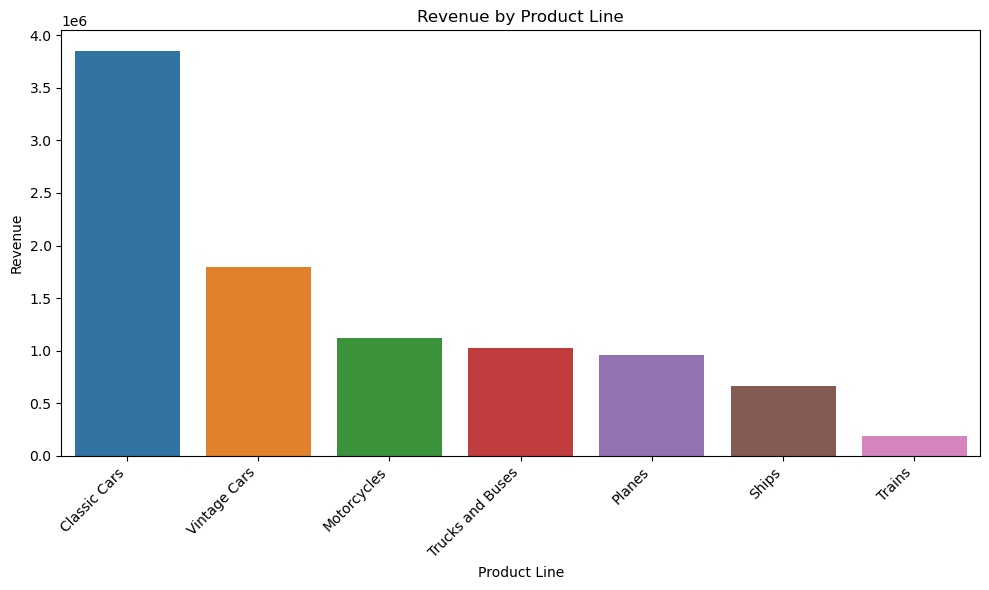

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=productline_revenue.index,
    y=productline_revenue.values
)

plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/Revenue_by_Product_Line.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.4 Revenue Share of the Top 2 Product Lines

This section calculates how much of the company’s total revenue is generated by the two largest product lines.

In [21]:
# Який % від всіх продажів становлять продажі за ТОП2 лініями сумарно

sum_revenue_top2 = productline_revenue.head(2).sum()
total_prodLine_revenue = productline_revenue.sum()

pct_productline_revenue_top2 = (sum_revenue_top2 / total_prodLine_revenue) *100

print(
    f"Top 2 product lines generate "
    f"{pct_productline_revenue_top2:.2f}% of total revenue."
)

Top 2 product lines generate 58.84% of total revenue.


Classic Cars and Vintage Cars are the two largest product lines by revenue. Together, they generate approximately 58.84% of total revenue, which means that more than half of the company’s revenue comes from these two categories.

### 4.5 Pareto Analysis

In [22]:
# за принципом Парето (80/20) - скільки продуктів дають 80% доходу.
# cumsum() = cumulative sum

cumsum = df_product_revenue["pct_of_total"].cumsum()

pareto_count = cumsum.le(80).sum() + 1        # le(80).sum() рахує прод до cumulative <= 80, треба додати 1, щоб включити прод, який “перетнув” 80%

print(f"{pareto_count:.0f} products generate approximately 80% of revenue")

72 products generate approximately 80% of revenue


The Pareto analysis shows that approximately 72 products generate 80% of total revenue. This indicates that revenue is distributed across a relatively large number of products rather than being concentrated in a very small group of bestsellers.

### 4.6 Top Product Revenue Compared to Product Line Average

This section compares the top product in each product line with the average product revenue within the same product line. The goal is to understand how strongly the leading product outperforms the average product in its category.

In [23]:
# топ в кожній лінійці

top_prod_in_productline = (
    df_product_revenue
    .sort_values("revenue", ascending=False)
    .groupby("productLine")
    .first()
)
top_prod_in_productline[["productName", "revenue", "pct_diff_from_line_avg"]]

,productName,revenue,pct_diff_from_line_avg
productLine,,,
Classic Cars,1992 Ferrari 360 Spider red,276839.98,165.776421
Motorcycles,2003 Harley-Davidson Eagle Drag Bike,170686.00,97.831290
Planes,1980s Black Hawk Helicopter,144959.91,82.217737
Ships,18th century schooner,112427.12,52.386538
Trains,Collectable Wooden Train,82617.12,31.463174
Trucks and Buses,1958 Setra Bus,119085.25,27.909422
Vintage Cars,1917 Grand Touring Sedan,140535.60,87.635188


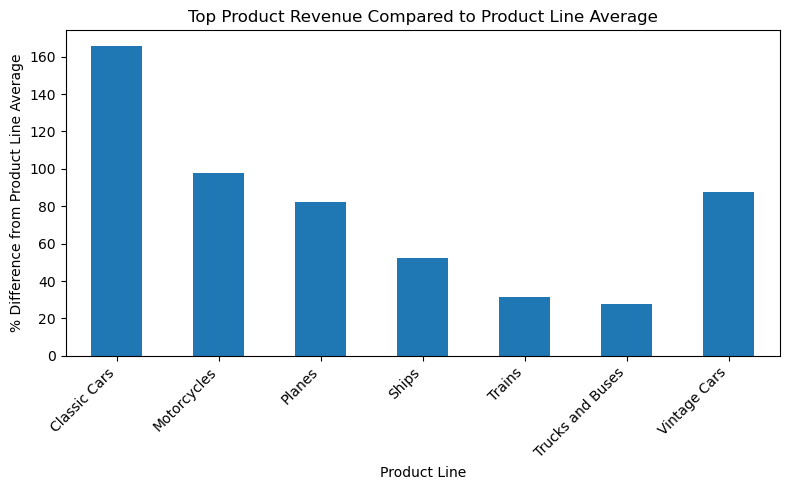

In [24]:
plt.figure(figsize=(8,5))

top_prod_in_productline["pct_diff_from_line_avg"].plot(kind="bar")

# Топ продукти в порівнянні із середнійм доходом у їх продуктовій лінійці
plt.title("Top Product Revenue Compared to Product Line Average")
plt.xlabel("Product Line")
plt.ylabel("% Difference from Product Line Average")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/TopProductRevenue_Compared_to_ProductLineAverage.png", dpi=300, bbox_inches="tight")
plt.show()


### 4.7 Top Product Share of Product Line Revenue

This section calculates what percentage of each product line’s revenue is generated by its top-selling product.
This helps identify product lines that may be highly dependent on a single product.

In [25]:
# частка топ
top_prod_in_productline_share = (top_prod_in_productline["revenue"] / productline_revenue) *100
top_prod_in_productline_share

productLine
Classic Cars         7.183147
Motorcycles         15.217792
Planes              15.184811
Ships               16.931838
Trains              43.821058
Trucks and Buses    11.628129
Vintage Cars         7.818133
Name: revenue, dtype: float64

In [26]:
# копіюю аби доповнити

top_prod_in_productline_share = top_prod_in_productline[["productName", "revenue"]].copy()

top_prod_in_productline_share["line_revenue"] = productline_revenue
top_prod_in_productline_share["pct_top_product_share"] = (
    top_prod_in_productline_share["revenue"] / top_prod_in_productline_share["line_revenue"]) * 100

top_prod_in_productline_share

,productName,revenue,line_revenue,pct_top_product_share
productLine,,,,
Classic Cars,1992 Ferrari 360 Spider red,276839.98,3854021.07,7.183147
Motorcycles,2003 Harley-Davidson Eagle Drag Bike,170686.00,1121621.36,15.217792
Planes,1980s Black Hawk Helicopter,144959.91,954637.54,15.184811
Ships,18th century schooner,112427.12,663998.34,16.931838
Trains,Collectable Wooden Train,82617.12,188532.92,43.821058
Trucks and Buses,1958 Setra Bus,119085.25,1024113.57,11.628129
Vintage Cars,1917 Grand Touring Sedan,140535.60,1797559.63,7.818133


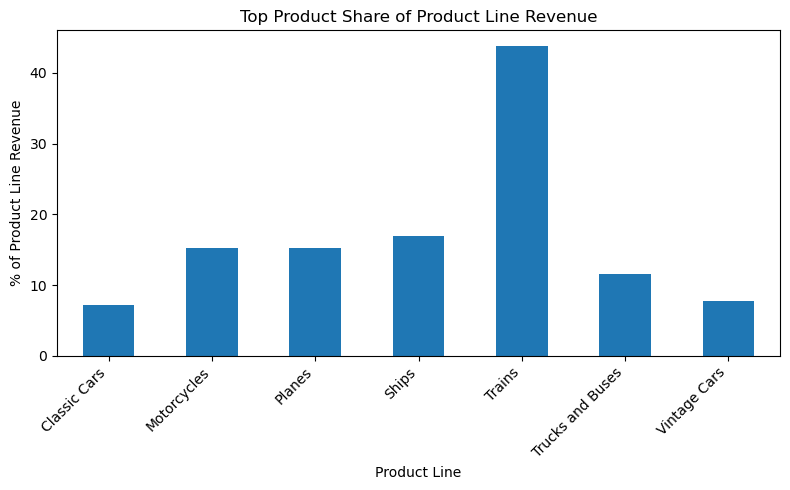

In [27]:
plt.figure(figsize=(8,5))

top_prod_in_productline_share["pct_top_product_share"].plot(kind="bar")

# Частка доходу ТОП продукту в кожній лінійці
plt.title("Top Product Share of Product Line Revenue")
plt.xlabel("Product Line")
plt.ylabel("% of Product Line Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/TopProductShare_of_ProductLineRevenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The analysis shows that the level of revenue concentration differs significantly across product lines.

In the Trains category, the top product generates more than 43% of the total revenue of its product line. This indicates a high dependency on a single product and may represent a concentration risk.

In contrast, Classic Cars and Vintage Cars have much lower top-product shares, around 7–8%. This suggests that these product lines have a more diversified and balanced revenue structure.

Overall, the company’s total revenue is not highly dependent on one single product, but some smaller product lines may still rely heavily on their leading product.

## 5. Monthly Sales Dynamics

This section analyzes how sales changed over time by month. It includes monthly revenue, revenue growth, order count, moving average, seasonality, and the relationship between the number of orders and average order value.

In [28]:
# аналіз динаміки продажів по місяцях

sales_dynamics_by_month_query = text("""
    WITH sales_dynamics_cte AS (
        SELECT 
            YEAR(o.orderDate) AS order_year,
            MONTH(o.orderDate) AS order_month,
            COUNT(DISTINCT o.orderNumber) AS number_of_orders,
            SUM(od.quantityOrdered * od.priceEach) AS income 
        FROM orders AS o
        JOIN orderdetails AS od
        ON  o.orderNumber = od.orderNumber
        GROUP BY order_year, order_month
    ),
    metrics_cte AS (
        SELECT
        order_year, order_month, number_of_orders, income,                            
        LAG(income) OVER (ORDER BY order_year, order_month) AS previous_income,             /*дохід за попередній міс для % зростання*/
        SUM(income) OVER (PARTITION BY order_year ORDER BY order_month) AS accumulated_year_income,      /*накопичувати окремо за рік*/
        AVG(income) OVER (ORDER BY order_year, order_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS rolling_avg_3m,  /*ковзне сер 3м (поточ, 2 поперед)*/
        RANK() OVER (ORDER BY income DESC) AS revenue_rank
    FROM sales_dynamics_cte
    )
    SELECT
        order_year,
        order_month,
        number_of_orders,
        income,
        previous_income, 
        ((income - previous_income)/previous_income) *100 AS growth_pct,  /*% зростання*/
        rolling_avg_3m,
        accumulated_year_income,
        revenue_rank
    FROM metrics_cte
    ORDER BY order_year, order_month;
""")

df_sales_dynamics_by_month = pd.read_sql(sales_dynamics_by_month_query, con=engine)

print("Аналіз динаміки продажів по місяцях")
display(df_sales_dynamics_by_month.head())

Аналіз динаміки продажів по місяцях


,order_year,order_month,number_of_orders,income,previous_income,growth_pct,rolling_avg_3m,accumulated_year_income,revenue_rank
0,2003,1,5,116692.77,NaN,NaN,116692.770000,116692.77,29
1,2003,2,3,128403.64,116692.77,10.035643,122548.205000,245096.41,28
2,2003,3,6,160517.14,128403.64,25.009805,135204.516667,405613.55,26
3,2003,4,7,185848.59,160517.14,15.781150,158256.456667,591462.14,23
4,2003,5,6,179435.55,185848.59,-3.450680,175267.093333,770897.69,24


### 5.1 Monthly Revenue Trend

This chart shows monthly revenue over time and helps identify the overall sales trend.

In [29]:
# Лінійний графік доходу з трендом (аби показати, що тренд є)

df_sales_dynamics_by_month["date"] = pd.to_datetime(
    df_sales_dynamics_by_month["order_year"].astype(str)
    + "-"
    + df_sales_dynamics_by_month["order_month"].astype(str)
    + "-01")

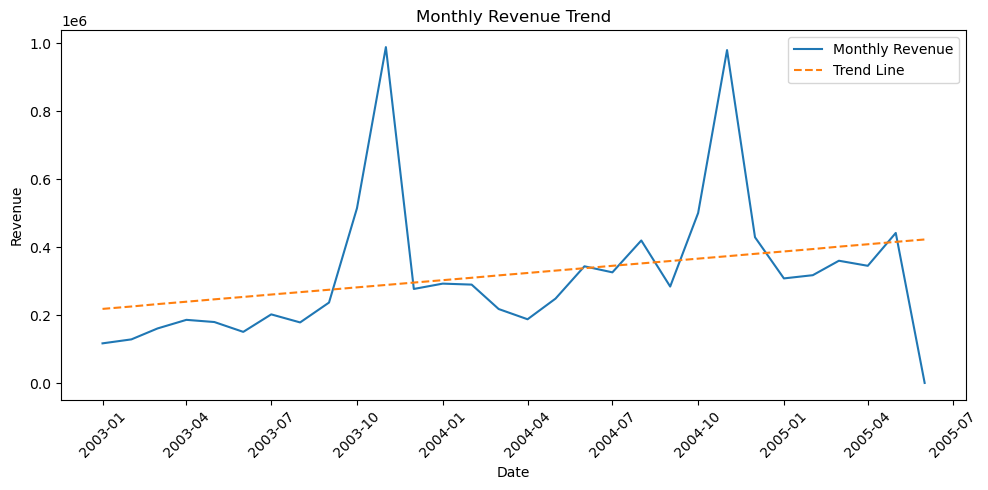

In [30]:
plt.figure(figsize=(10,5))

# Основна лінія доходу
plt.plot(
    df_sales_dynamics_by_month["date"],
    df_sales_dynamics_by_month["income"],
    label="Monthly Revenue"
)

# Лінія тренду
x = np.arange(len(df_sales_dynamics_by_month))
y = df_sales_dynamics_by_month["income"]

trend_coefficients = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend_coefficients)

plt.plot(
    df_sales_dynamics_by_month["date"],
    trend_line(x),
    linestyle="--",
    label="Trend Line"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("../images/MonthlyRevenueTrend.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Monthly revenue shows an overall upward trend despite strong fluctuations and recurring peaks. The highest revenue peaks appear around October and November, which suggests a possible seasonal pattern.

The final month in the dataset is unusually low and may represent incomplete data, so it should be interpreted with caution.

### 5.2 Month-over-Month Revenue Growth

This chart shows how monthly revenue changed compared to the previous month.

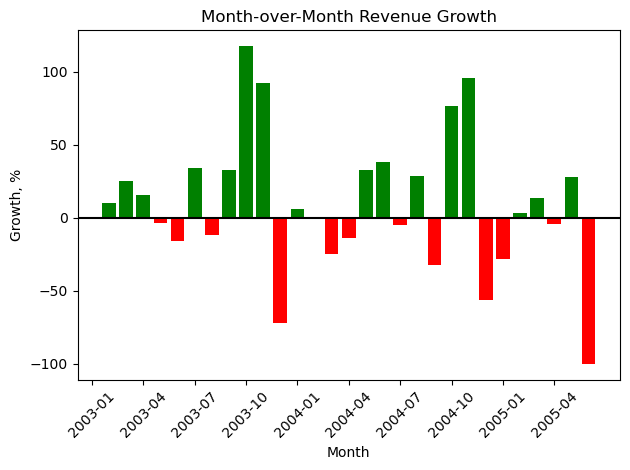

In [31]:
# 2. Місяць-до-місяця зростання

# підпис для осі X - рік перетворити на текст, зєднати з місяцем перетвореним на текст, 0перед місяцем
df_sales_dynamics_by_month["year_month"] =  df_sales_dynamics_by_month["date"].dt.strftime("%Y-%m")

colors = np.where(
    df_sales_dynamics_by_month["growth_pct"] >= 0,
    "green",
    "red")

plt.bar(df_sales_dynamics_by_month["year_month"],
        df_sales_dynamics_by_month["growth_pct"],
        color=colors)

plt.axhline(0, color="black")
             
plt.title("Month-over-Month Revenue Growth")
plt.ylabel("Growth, %")
plt.xlabel("Month")
plt.xticks(
    ticks=range(0, len(df_sales_dynamics_by_month), 3),
    labels=df_sales_dynamics_by_month["year_month"][::3],
    rotation=45)

#plt.grid()

plt.tight_layout()  

plt.savefig("../images/Month_over_Month_RevenueGrowth.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Month-over-month growth is volatile: periods of strong revenue increase are followed by noticeable declines. This indicates that monthly sales dynamics are uneven and may be influenced by seasonality or several large orders in specific months.

### 5.3 Revenue Seasonality Heatmap

This heatmap shows monthly revenue by year and helps identify recurring seasonal peaks.

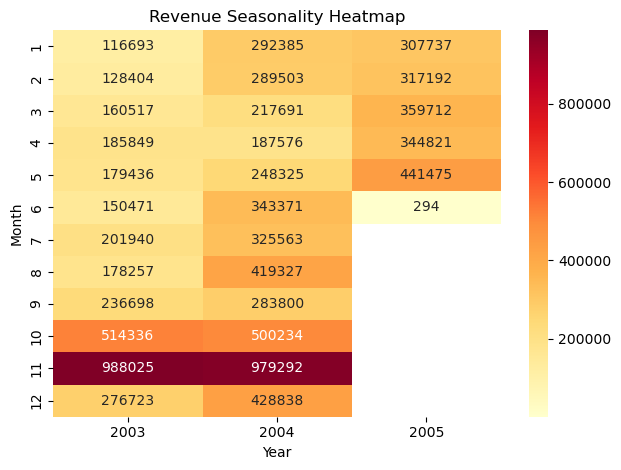

In [32]:
# Heatmap сезонності

heatmap_season = df_sales_dynamics_by_month.pivot(
    index="order_month",
    columns="order_year",
    values="income")

sns.heatmap(heatmap_season, cmap="YlOrRd", annot=True, fmt=".0f")

plt.title("Revenue Seasonality Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")

plt.tight_layout()
plt.savefig("../images/RevenueSeasonalityHeatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The heatmap confirms a seasonal pattern: the highest revenue appears in October and November across multiple years. This may indicate seasonal demand or increased customer activity during this period.

### 5.4 Three-Month Moving Average

This chart compares actual monthly revenue with a three-month moving average to make the overall trend easier to interpret.

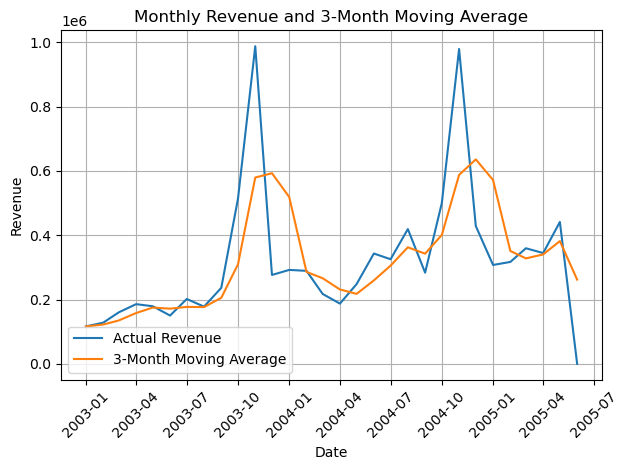

In [33]:
plt.plot(
    df_sales_dynamics_by_month["date"],
    df_sales_dynamics_by_month["income"],
    label="Actual Revenue",
    #color="blue"
    
)

plt.plot(
    df_sales_dynamics_by_month["date"],
    df_sales_dynamics_by_month["rolling_avg_3m"],
    label="3-Month Moving Average",
    #color="red"
)

plt.title("Monthly Revenue and 3-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid()
plt.legend()

plt.tight_layout()
plt.savefig("../images/MonthlyRevenue_and_3MonthMovingAverage.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The three-month moving average smooths short-term fluctuations and makes the general upward trend easier to see. It also confirms that revenue peaks are recurring rather than completely random.

### 5.5 Relationship Between Order Count and Average Order Value

This section checks whether months with more orders also tend to have a higher average order value.

In [34]:
df_sales_dynamics_by_month["avg_check"] = (
    df_sales_dynamics_by_month["income"] /
    df_sales_dynamics_by_month["number_of_orders"])

In [35]:
# Кореляція замовлень та середнього чеку
correlation = df_sales_dynamics_by_month["number_of_orders"].corr(
    df_sales_dynamics_by_month["avg_check"])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.20


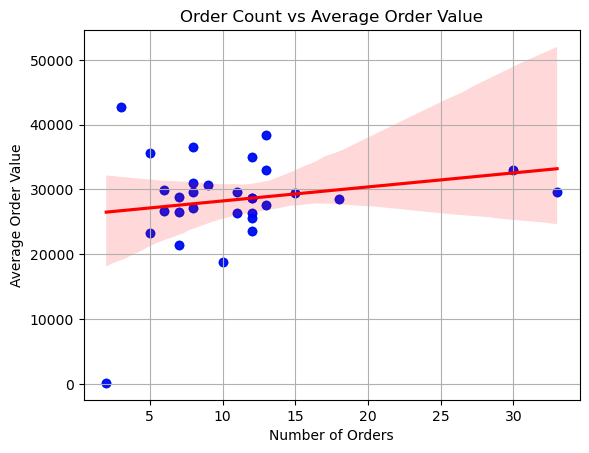

In [36]:
plt.scatter(
    df_sales_dynamics_by_month["number_of_orders"],
    df_sales_dynamics_by_month["avg_check"])

sns.regplot(
    data=df_sales_dynamics_by_month,
    x="number_of_orders",
    y="avg_check",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"}
)

plt.title("Order Count vs Average Order Value")
plt.xlabel("Number of Orders")
plt.ylabel("Average Order Value")

plt.grid()
plt.savefig("../images/OrderCount_vs_AverageOrderValue.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The correlation between the number of orders and average order value is close to zero. This suggests that months with more orders do not necessarily have higher average order values.

The scatter plot also shows several outliers, but overall there is no clear linear relationship between order volume and average order value.

## 6. Key Insights and Conclusion

This analysis identified several important business insights:

- The United States is the strongest revenue market in 2004.
- Mini Gifts Distributors Ltd. is the top customer in the USA and accounts for a noticeable share of the country’s annual order amount.
- The company’s total revenue is not overly dependent on a single product, as the top product contributes only about 2.88% of total revenue.
- Classic Cars and Vintage Cars are the strongest product lines and together generate more than half of total revenue.
- The Trains product line shows high internal concentration, with one product generating more than 43% of the line’s revenue.
- Monthly sales show recurring peaks around October and November, suggesting a seasonal pattern.
- The relationship between order count and average order value is weak, which means that more orders do not necessarily lead to a higher average order value.

Overall, the analysis shows that the company has a diversified product portfolio at the company level, but some product lines and customer segments require monitoring due to concentration risks.